In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier

Paths to the folders containing the images

In [2]:
birds= Path("dataset/bird")
drones= Path("dataset/drone")

Remove .png files and edit .jpeg to .jpg (if file exists with same name, then remove)

In [3]:
for file in os.listdir(birds):
    if file.endswith('.png'):
        os.remove(os.path.join(birds,file))
    if file.endswith('.jpeg'):
        new_path=os.path.join(birds,file[:-5]+'.jpg')
        if os.path.exists(new_path):
            os.remove(os.path.join(birds,file))
        else:
            os.rename(os.path.join(birds,file),new_path)

for file in os.listdir(drones):
    if file.endswith('.png'):
        os.remove(os.path.join(drones,file))
    if file.endswith('.jpeg'):
        new_path=os.path.join(drones,file[:-5]+'.jpg')
        if os.path.exists(new_path):
            os.remove(os.path.join(birds,file))
        else: 
            os.rename(os.path.join(drones,file),new_path)



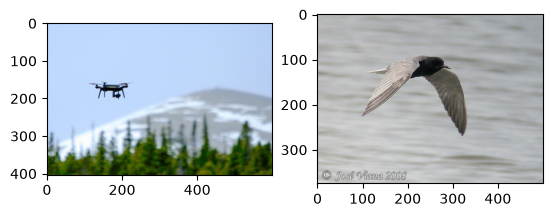

In [4]:
#check first image from both

fig, axes = plt.subplots(1, 2)

axes[0].imshow(Image.open(os.path.join(drones, os.listdir(drones)[0])))


axes[1].imshow(Image.open(os.path.join(birds, os.listdir(birds)[0])))

In [5]:
#Load data into X and y (convert images to matrixes, resize and convert to rgb)

XValues=[]
yValues=[]

for file in os.listdir(drones):
    if file.endswith('.jpg'):
        img= Image.open(os.path.join(drones,file)).resize((224,224)).convert('RGB')
        XValues.append(np.asarray(img))
        yValues.append(0)

for file in os.listdir(birds):
    if file.endswith('.jpg'):
        img= Image.open(os.path.join(birds,file)).resize((224,224)).convert('RGB')
        XValues.append(np.asarray(img))
        yValues.append(1)

X= np.array(XValues)
y= np.array(yValues)
        

In [6]:
#Normalize the X array from 255 to values 0-1
X=X/255

In [7]:
#Show first element of X matrix, shape and rgb values for first pixel

print(X[0])
print("Shape", X[0].shape)
print("RGB Values:", X[0][0, 0])

[[[0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  ...
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]]

 [[0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  ...
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]]

 [[0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  ...
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]]

 ...

 [[0.12941176 0.29411765 0.        ]
  [0.14901961 0.26666667 0.00392157]
  [0.15294118 0.21960784 0.01176471]
  ...
  [0.25882353 0.36862745 0.00784314]
  [0.26666667 0.38431373 0.00784314]
  [0.26666667 0.38431373 0.        ]]

 [[0.16862745 0.29803922 0.        ]
  [0.19607843 0.2745098  0.00392157]


In [8]:
#crete splits (75%, 10% and 15%)

X_train, X_temp, y_train, y_temp = train_test_split(X, y,
    test_size=0.25,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,
    test_size=0.60,
    random_state=42
)


In [9]:
print(f"Train Amount: {len(X_train)}")
print(f"Validation Amount: {len(X_val)}")
print(f"Test Amount: {len(X_test)}")
print(f"All: {len(X_train)+len(X_val)+len(X_test)}")

Train Amount: 2614
Validation Amount: 348
Test Amount: 524
All: 3486


In [10]:
print("Kuvien määrä Y_trainissa:", len(y_train))
print("Luokan 0 (dronet/binit) määrä:", np.sum(y_train == 0))
print("Luokan 1 (binit/dronet) määrä:", np.sum(y_train == 1))
print("Luokan 1 osuus kaikista:", np.mean(y_train))

Kuvien määrä Y_trainissa: 2614
Luokan 0 (dronet/binit) määrä: 1640
Luokan 1 (binit/dronet) määrä: 974
Luokan 1 osuus kaikista: 0.3726090283091048


Data augmentation to train set

In [16]:
data_augmentation = models.Sequential([
    
    layers.RandomFlip("horizontal"),
    
], name="data_augmentation")

In [17]:
#Model


model = models.Sequential([
    
    layers.Input(shape=(224, 224, 3)),
    
 
    data_augmentation,
    
    
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

model.summary()

#
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict
    )

Lasketut painot: {0: np.float64(0.7969512195121952), 1: np.float64(1.341889117043121)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,457 (49.36 MB)

 Trainable params: 12,939,009 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 76s 906ms/step - accuracy: 0.8787 - auc: 0.9385 - loss: 0.3466 - val_accuracy: 0.6724 - val_auc: 0.8045 - val_loss: 0.6090
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 73s 890ms/step - accuracy: 0.9101 - auc: 0.9712 - loss: 0.2206 - val_accuracy: 0.7011 - val_auc: 0.8468 - val_loss: 0.5500
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 78s 955ms/step - accuracy: 0.9258 - auc: 0.9801 - loss: 0.1813 - val_accuracy: 0.8879 - val_auc: 0.9329 - val_loss: 0.3554
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 75s 910ms/step - accuracy: 0.9353 - auc: 0.9818 - loss: 0.1728 - val_accuracy: 0.8966 - val_auc: 0.9539 - val_loss: 0.2565
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 73s 890ms/step - accuracy: 0.9376 - auc: 0.9871 - loss: 0.1459 - val_accuracy: 0.9195 - val_auc: 0.9734 - val_loss: 0.2099
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 72s 882ms/step - accuracy: 0.9579 - auc: 0.9914 - loss: 0.1146 - val_accuracy: 0.9339 - val_auc: 0.9854 - val_loss: 0.1562
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.9523 - auc: 0.9894 - loss: 0.1377

Test Dataset Accuracy: 95.23%
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step

 Raport:
              precision    recall  f1-score   support

   Drone (0)       0.95      0.97      0.96       331
    Bird (1)       0.95      0.92      0.93       193

    accuracy                           0.95       524
   macro avg       0.95      0.94      0.95       524
weighted avg       0.95      0.95      0.95       524



<Figure size 600x600 with 0 Axes>

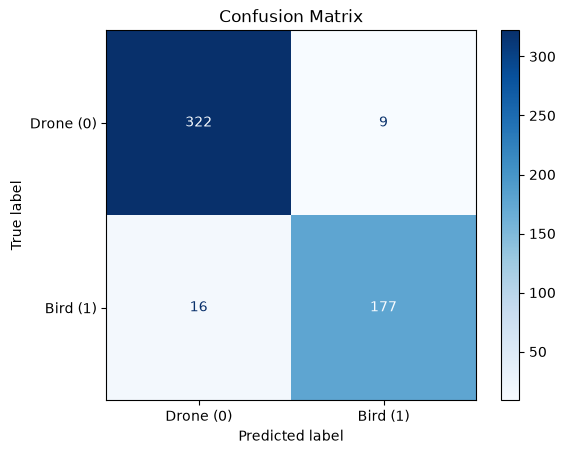

In [ ]:
#CNN evaluation (accuracy and confusion matrix)

test_loss, test_acc, test_auc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Dataset Accuracy: {test_acc * 100:.2f}%")


y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

print("\n Raport:")
print(classification_report(y_test, y_pred, target_names=['Drone (0)', 'Bird (1)']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Drone (0)', 'Bird (1)'])

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:

#Augmentation added
X_train_augmented = data_augmentation(X_train).numpy()

# MLP method
X_train_flat = X_train_augmented.reshape(X_train_augmented.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), 
    max_iter=100, 
    random_state=42,
    verbose=True
)

mlp_sklearn.fit(X_train_flat, y_train)


Iteration 1, loss = 4.66829401
Iteration 2, loss = 4.39886340
Iteration 3, loss = 4.51387355
Iteration 4, loss = 2.84956838
Iteration 5, loss = 2.42479958
Iteration 6, loss = 1.38325091
Iteration 7, loss = 1.37016795
Iteration 8, loss = 0.68770639
Iteration 9, loss = 0.51370907
Iteration 10, loss = 1.57526789
Iteration 11, loss = 1.05990550
Iteration 12, loss = 0.50579536
Iteration 13, loss = 0.85202304
Iteration 14, loss = 0.68602922
Iteration 15, loss = 0.67750500
Iteration 16, loss = 3.16349397
Iteration 17, loss = 1.15342549
Iteration 18, loss = 1.15659085
Iteration 19, loss = 0.43688941
Iteration 20, loss = 0.60228246
Iteration 21, loss = 0.85837538
Iteration 22, loss = 1.01145994
Iteration 23, loss = 0.82837334
Iteration 24, loss = 1.21138968
Iteration 25, loss = 0.66280102
Iteration 26, loss = 0.69751541
Iteration 27, loss = 0.41692714
Iteration 28, loss = 0.52369375
Iteration 29, loss = 0.32007288
Iteration 30, loss = 0.33868324
Iteration 31, loss = 0.30504080
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5


Test accuracy: 89.12 %

 Raport:
              precision    recall  f1-score   support

   Drone (0)       0.88      0.95      0.92       331
    Bird (1)       0.90      0.79      0.84       193

    accuracy                           0.89       524
   macro avg       0.89      0.87      0.88       524
weighted avg       0.89      0.89      0.89       524



<Figure size 600x600 with 0 Axes>

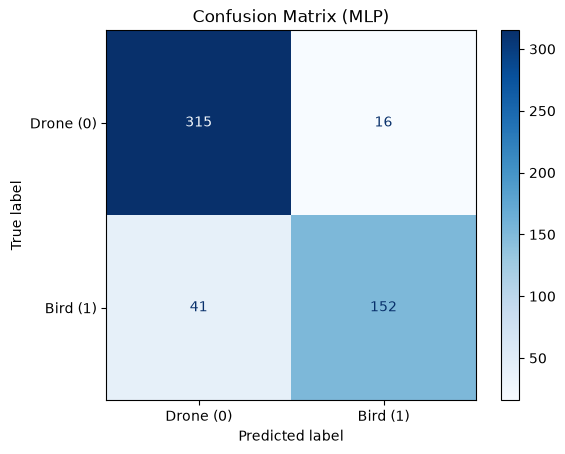

In [39]:
#MLP evaluation (accuracy and confusion matrix)


print(f"Test accuracy: {mlp_sklearn.score(X_test_flat, y_test) * 100:.2f} %")
y_pred = mlp_sklearn.predict(X_test_flat)

print("\n Raport:")
print(classification_report(y_test, y_pred, target_names=['Drone (0)', 'Bird (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Drone (0)', 'Bird (1)'])

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (MLP)")
plt.show()